<a href="https://colab.research.google.com/github/d16ago-lgtm/jit-tracing-hw3/blob/main/torch_compile_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch torch.compile Analysis

This notebook analyzes the performance and behavior of PyTorch's
`torch.compile` feature.

We compare different compilation backends, debug compilation failures,
and inspect the computation graphs captured by the compiler.

## Part 1: Comparing Compilation Backends

PyTorch 2.0 supports multiple compilation backends.

In this experiment we compare:
- eager
- aot_eager
- inductor
- cudagraphs

We measure execution time for forward and backward passes
to evaluate performance differences.

Using device: cuda

Running backend: eager
Average Time: 0.001163785457611084

Running backend: aot_eager
Average Time: 0.001412684917449951

Running backend: inductor
Average Time: 0.0015775585174560547

Running backend: cudagraphs
Average Time: 0.0014073634147644043


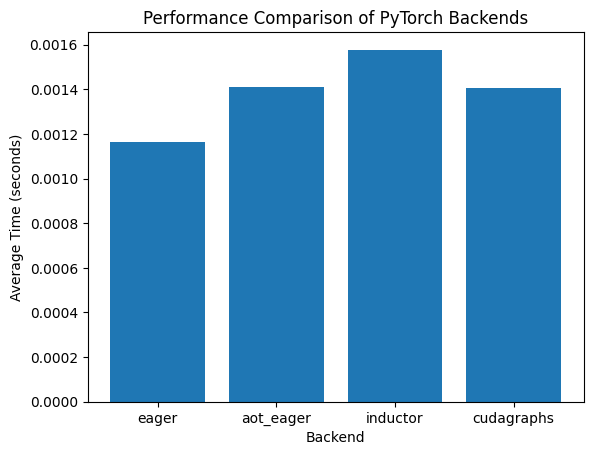

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 128)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

backends = ["eager", "aot_eager", "inductor", "cudagraphs"]

x = torch.randn(256, 512).to(device)
y = torch.randn(256, 128).to(device)

criterion = nn.MSELoss()
results = {}

for backend in backends:
    print(f"\nRunning backend: {backend}")

    model = SimpleNN().to(device)
    compiled_model = torch.compile(model, backend=backend)
    optimizer = optim.SGD(compiled_model.parameters(), lr=0.01)

    # warm-up
    output = compiled_model(x)
    loss = criterion(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for _ in range(100):
        output = compiled_model(x)
        loss = criterion(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if device == "cuda":
        torch.cuda.synchronize()

    end = time.time()

    avg_time = (end - start) / 100
    results[backend] = avg_time
    print("Average Time:", avg_time)

plt.bar(results.keys(), results.values())
plt.xlabel("Backend")
plt.ylabel("Average Time (seconds)")
plt.title("Performance Comparison of PyTorch Backends")
plt.show()

## Part 2: Debugging torch.compile Failures

Some Python constructs prevent efficient compilation.

We test several problematic functions and use
`torch._dynamo.explain()` to understand why compilation fails
or produces suboptimal graphs.

We then modify the functions to improve compilation.

In [ ]:
import torch

# Input tensor
x = torch.ones(5000, 5000, device="cuda")



# Problem 1: Broken version
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

# Compile the function
p1_compiled = torch.compile(problem1)

print("\n--- Problem 1 Broken ---")

# First call: capture + compile
try:
    y = p1_compiled(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

# Explain why
print(torch._dynamo.explain(problem1)(x))



# Problem 1: Fixed version
def problem1_fixed(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

# Compile the fixed function
p1_fixed_compiled = torch.compile(problem1_fixed)

print("\n--- Problem 1 Fixed ---")

# First call: capture + compile
try:
    y = p1_fixed_compiled(x)
    print("Fixed version compiled successfully")
except Exception as e:
    print("Fixed version compilation failed:", e)

# Explain fixed version
print(torch._dynamo.explain(problem1_fixed)(x))



# Problem 2: Broken version
def problem2(x):
    d = {}
    d["key"] = x
    return d["key"] * 2

# Compile the function
p2_compiled = torch.compile(problem2)

print("\n--- Problem 2 Broken ---")

# First call: capture + compile
try:
    y = p2_compiled(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

# Explain why
print(torch._dynamo.explain(problem2)(x))



# Problem 2: Fixed version
def problem2_fixed(x):
    return x * 2

# Compile the fixed function
p2_fixed_compiled = torch.compile(problem2_fixed)

print("\n--- Problem 2 Fixed ---")

# First call: capture + compile
try:
    y = p2_fixed_compiled(x)
    print("Fixed version compiled successfully")
except Exception as e:
    print("Fixed version compilation failed:", e)

# Explain fixed version
print(torch._dynamo.explain(problem2_fixed)(x))



# Problem 3: Broken version
def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

# Compile the function
p3_compiled = torch.compile(problem3)

print("\n--- Problem 3 Broken ---")

# First call: capture + compile
try:
    y = p3_compiled(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

# Explain why
print(torch._dynamo.explain(problem3)(x))



# Problem 3: Fixed version
def problem3_fixed(x):
  return torch.sum(torch.stack([torch.sum(x ** i) for i in range(10)]))

# Compile the fixed function
p3_fixed_compiled = torch.compile(problem3_fixed)

print("\n--- Problem 3 Fixed ---")

# First call: capture + compile
try:
    y = p3_fixed_compiled(x)
    print("Fixed version compiled successfully")
except Exception as e:
    print("Fixed version compilation failed:", e)

# Explain fixed version
print(torch._dynamo.explain(problem3_fixed)(x))


--- Problem 1 Broken ---
Compilation succeeded
Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_31851/3920293154.py, line 11 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types

## Part 3: Graph Capture and Inspection

This experiment investigates which operations are captured
by `torch.compile`.

We include both tensor operations and Python operations
in the same function to observe how the compiler handles them.

In [ ]:
import torch
import torch.nn.functional as F
from torch.fx import symbolic_trace

def capture_test(x, w1, w2):

    h = x @ w1
    h = torch.relu(h)
    h = h @ w2
    h = h + x
    h = F.layer_norm(h, h.shape[-1:])

    return h


x = torch.randn(4,4)
w1 = torch.randn(4,4)
w2 = torch.randn(4,4)

compiled = torch.compile(capture_test, fullgraph=True)
print(torch._dynamo.explain(capture_test)(x, w1, w2))

# Trace the function
traced = symbolic_trace(capture_test)

# Print the intermediate graph
print(traced.graph)

graph():
    %x : [num_users=2] = placeholder[target=x]
    %w1 : [num_users=1] = placeholder[target=w1]
    %w2 : [num_users=1] = placeholder[target=w2]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %matmul_1 : [num_users=1] = call_function[target=operator.matmul](args = (%relu, %w2), kwargs = {})
    %add : [num_users=2] = call_function[target=operator.add](args = (%matmul_1, %x), kwargs = {})
    %getattr_1 : [num_users=1] = call_function[target=builtins.getattr](args = (%add, shape), kwargs = {})
    %getitem : [num_users=1] = call_function[target=operator.getitem](args = (%getattr_1, slice(-1, None, None)), kwargs = {})
    %layer_norm : [num_users=1] = call_function[target=torch.nn.functional.layer_norm](args = (%add, %getitem), kwargs = {weight: None, bias: None, eps: 1e-05})
    return layer_norm
